## Wczytanie bibliotek oraz wstępne przygotowanie zbioru danych ElectricProduction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#reading the dataset
train = pd.read_csv('Electric_Production.csv')

#preprocessing

train.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


# Metody sprawdzania stacjonarności

<Axes: >

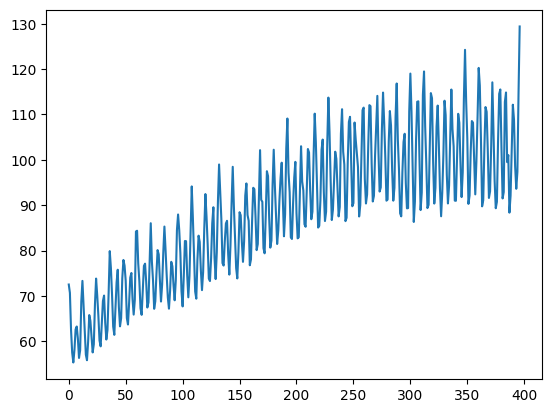

In [3]:
train['Value'].plot()

## Definicja funkcji testu Dickeya-Fullera (ADF) i jego wykonanie

In [4]:
#define function for ADF test
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

#apply adf test on the series
adf_test(train['Value'])

Results of Dickey-Fuller Test:
Test Statistic                  -2.256990
p-value                          0.186215
#Lags Used                      15.000000
Number of Observations Used    381.000000
Critical Value (1%)             -3.447631
Critical Value (5%)             -2.869156
Critical Value (10%)            -2.570827
dtype: float64


### Definicja i wykonanie testu KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [6]:
from statsmodels.tsa.stattools import kpss
#define KPSS
def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)
kpss_test(train['Value'])

Results of KPSS Test:
Test Statistic            3.531597
p-value                   0.010000
Lags Used                10.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Users\Kamil\AppData\Local\Temp\ipykernel_14344\3295240343.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression='c')


### Tworzenie szeregu czasowego stacjonarnego


<Axes: >

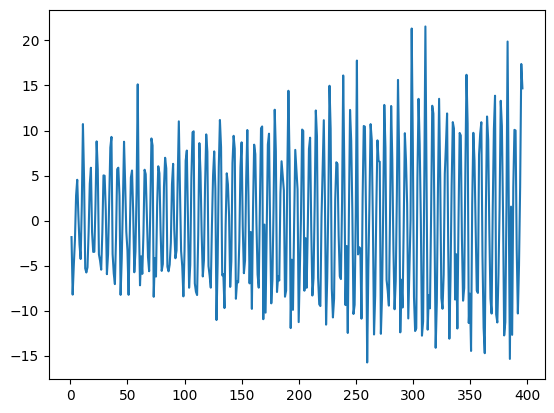

In [8]:
train['Value_diff'] = train['Value'] - train['Value'].shift(1)
train['Value_diff'].dropna().plot()

## Różnicowanie sezonowe


<Axes: >

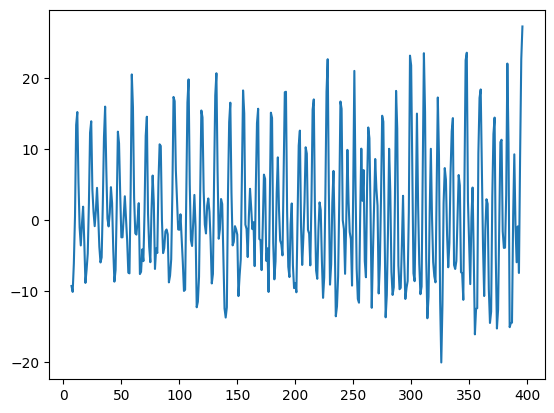

In [9]:
n=7
train['Value_diff'] = train['Value'] - train['Value'].shift(n)
train['Value_diff'].dropna().plot()

### Transformacja: Logarytmowanie danych, obliczenie różnic logarytmicznych i wyrysowanie wykresu

<Axes: >

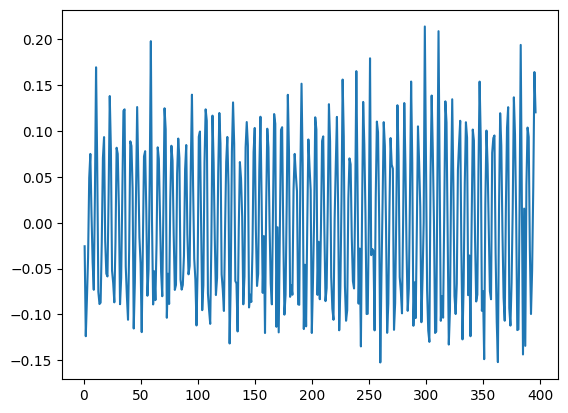

In [10]:
train['Value_log'] = np.log(train['Value'])
train['Value_log'] = train['Value_log'] - train['Value_log'].shift(1)
train['Value_log'].dropna().plot()